In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os

In [62]:
import os

def load_images(folder):
    images = []
    names = []

    for file in sorted(os.listdir(folder)):
        path = os.path.join(folder, file)
        img = cv2.imread(path)

        if img is not None:
            images.append(img)
            names.append(file)

    print(f"Loaded {len(images)} images")
    return images, names

images, names = load_images("DeepGlobe_Dataset/fragments/")

Loaded 45 images


In [63]:
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    return gray

In [64]:
def extract_features(img):
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(img, None)
    return kp, des

def show_keypoints(img, kp, title):
    out = cv2.drawKeypoints(img, kp, None, color=(0,255,0))

    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [65]:
features = []

for i, img in enumerate(images):
    gray = preprocess(img)
    kp, des = extract_features(gray)
    features.append((kp, des))

    #show_keypoints(img, kp, f"Keypoints: {names[i]}")

In [66]:
def match_features(des1, des2):
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return good

In [67]:
def show_matches(img1, kp1, img2, kp2, matches, title):
    out = cv2.drawMatches(img1, kp1, img2, kp2, matches[:50], None)

    plt.figure(figsize=(10,5))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [69]:
def build_graph(features, images, threshold=40):

    G = nx.Graph()

    for i in range(len(images)):
        G.add_node(i)

    for i in range(len(images)):
        for j in range(i+1, len(images)):

            kp1, des1 = features[i]
            kp2, des2 = features[j]

            matches = match_features(des1, des2)

            if len(matches) > threshold:
                G.add_edge(i, j, weight=len(matches))

    return G

G = build_graph(features, images)

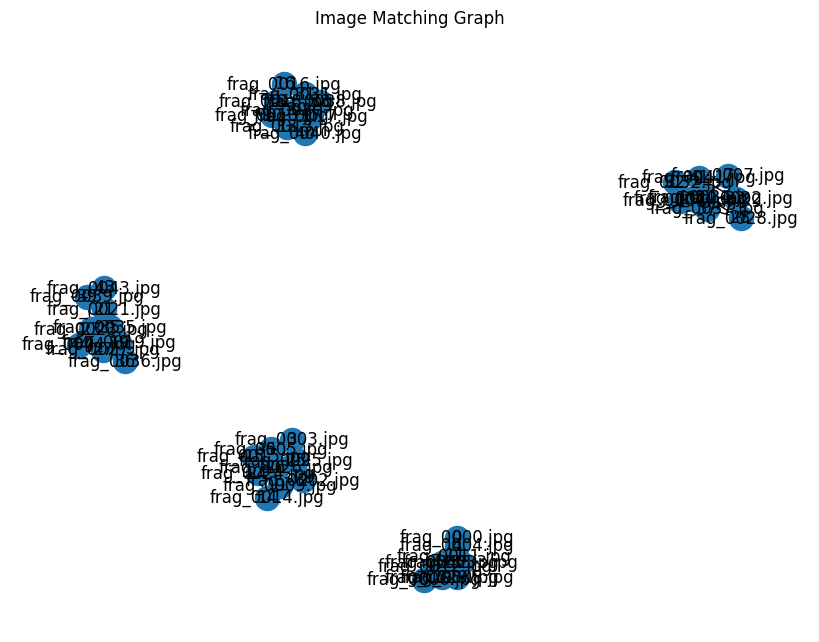

In [70]:
def show_graph(G, names):
    plt.figure(figsize=(8,6))

    #A Spring Layout is a type of network visualization algorithm that uses the principles of physics to position nodes in a way that reveals the structure of the network. 
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True)

    labels = {i: names[i] for i in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels)

    plt.title("Image Matching Graph")
    plt.show()

show_graph(G, names)

In [72]:
components = list(nx.connected_components(G))

print("Groups found:")
for comp in components:
    print(comp)

Groups found:
{0, 33, 4, 6, 8, 42, 11, 12, 29}
{32, 1, 34, 37, 7, 41, 20, 22, 28}
{2, 3, 5, 9, 14, 15, 24, 25, 26}
{38, 40, 10, 13, 16, 17, 18, 30, 31}
{35, 36, 39, 43, 44, 19, 21, 23, 27}


In [73]:
def build_mst(G, component):
    comp = list(component)
    mst = nx.maximum_spanning_tree(G.subgraph(comp))
    return list(mst.edges())

In [74]:
def compute_homography(i,j):
    kp1, des1 = features[i]
    kp2, des2 = features[j]

    matches = match_features(des1, des2)

    if len(matches) < 10:
        return None

    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

    H, _ = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
    return H

In [75]:
def compute_global_H(component, mst):

    root = list(component)[0]
    H_global = {root: np.eye(3)}

    adj = {i: [] for i in component}
    for u, v in mst:
        adj[u].append(v)
        adj[v].append(u)

    visited = set()

    def dfs(node):
        visited.add(node)

        for nei in adj[node]:
            if nei in visited:
                continue

            H = compute_homography(nei, node)
            if H is not None:
                H_global[nei] = H_global[node] @ H
                dfs(nei)

    dfs(root)
    return H_global

In [76]:
def find_seams(warped, masks, corners):
    seam_finder = cv2.detail_GraphCutSeamFinder("COST_COLOR")
    seam_finder.find(warped, corners, masks)
    return masks

In [77]:
def blend_final(warped, masks, corners):

    blender = cv2.detail_MultiBandBlender()
    blender.prepare((0, 0, 3000, 3000))

    for i in range(len(warped)):
        blender.feed(warped[i].astype(np.int16), masks[i], corners[i])

    result, _ = blender.blend(None, None)
    return cv2.convertScaleAbs(result)

In [78]:
def warp_all(images, H_global):

    all_corners = []

    # Collect ALL warped corners
    for i in H_global:
        H = H_global[i]
        h, w = images[i].shape[:2]

        corners = np.float32([[0,0],[0,h],[w,h],[w,0]]).reshape(-1,1,2)
        warped_corners = cv2.perspectiveTransform(corners, H)

        all_corners.append(warped_corners)

    all_corners = np.concatenate(all_corners, axis=0)

    xmin, ymin = np.int32(all_corners.min(axis=0).ravel())
    xmax, ymax = np.int32(all_corners.max(axis=0).ravel())

    # GLOBAL translation
    T = np.array([[1,0,-xmin],
                  [0,1,-ymin],
                  [0,0,1]])

    canvas_size = (xmax - xmin, ymax - ymin)

    warped = []
    masks = []
    corners = []

    # Warp ALL into SAME space
    for i in H_global:
        H = H_global[i]
        Ht = T @ H

        img = images[i]

        w_img = cv2.warpPerspective(img, Ht, canvas_size)

        mask = (w_img.sum(axis=2) > 0).astype(np.uint8) * 255

        warped.append(w_img.astype(np.float32))
        masks.append(mask)
        corners.append((0,0))  # ALL SAME FRAME

    return warped, masks, corners

In [79]:
def crop_black(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(thresh)
    x, y, w, h = cv2.boundingRect(coords)

    return img[y:y+h, x:x+w]

Processing group: {0, 33, 4, 6, 8, 42, 11, 12, 29}


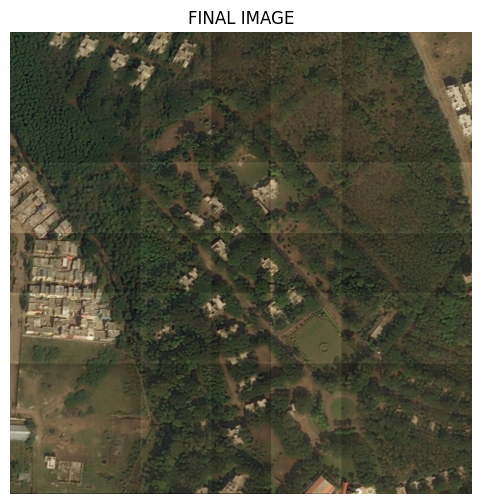

Processing group: {32, 1, 34, 37, 7, 41, 20, 22, 28}


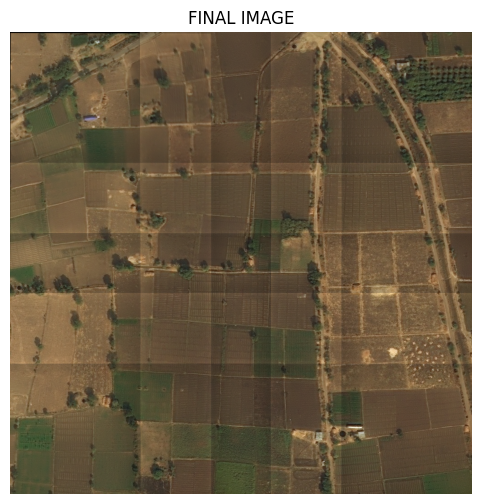

Processing group: {2, 3, 5, 9, 14, 15, 24, 25, 26}


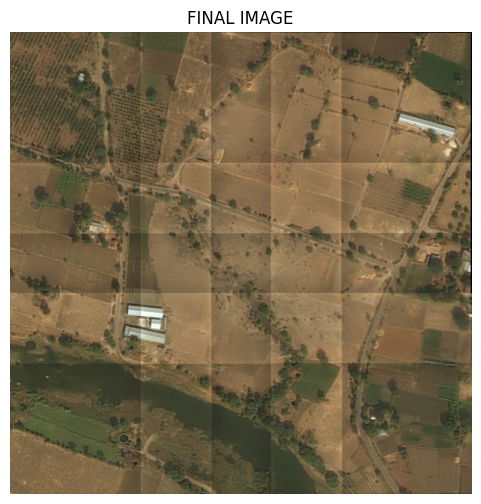

Processing group: {38, 40, 10, 13, 16, 17, 18, 30, 31}


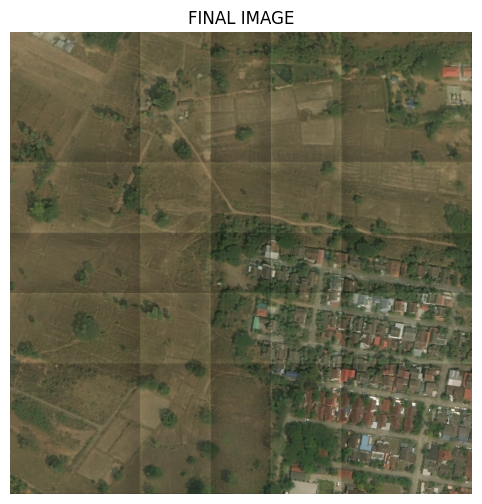

Processing group: {35, 36, 39, 43, 44, 19, 21, 23, 27}


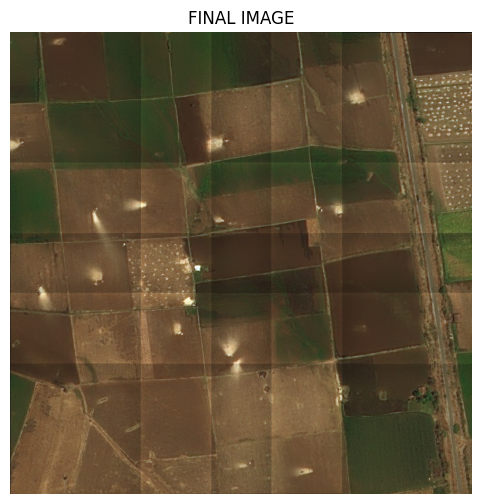

In [80]:
results = []

for comp in components:

    print(f"Processing group: {comp}")

    mst = build_mst(G, comp)

    H_global = compute_global_H(comp, mst)

    warped, masks, corners = warp_all(images, H_global)

    masks = find_seams(warped, masks, corners)

    result = blend_final(warped, masks, corners)

    result = crop_black(result)

    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title("FINAL IMAGE")
    plt.axis('off')
    plt.show()

    results.append(result)